In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def simulated_family(df):
    # Simulates wealth trajectories for one White, one Black, and one Reparation
    # family from 1860 to 2022 using systemic and probabilistic parameters.
    # Parameters used in the simulation are used from measurements of the parameters
    # made in previous research/ literature with sources attached below initialization

    years = df['Year'].values
    n_years = len(years)

    # Initialization
    w_w, w_b, w_b40 = (df.loc[0, 'Avg_Value_Per_Acre_USD'] * df.loc[0, 'Avg_Farm_Size_Acres']), 0.0, 0.0

    # Parameter initialization with sources attached from which the parameters are identified

    inc_w = 300.0  # Initial 1860 wage
    # Source: Statistics of the United States, (Including Mortality, Property, & C.,) in 1860, Government Printing Office (1866). Page 512, "Wages."

    traj_w, traj_b, traj_b40 = np.zeros((n_years, 4)), np.zeros((n_years, 4)), np.zeros((n_years, 4))
    traj_w[0] = w_w

    # Systemic & Probabilistic Parameters

    # Inflation Rate
    INC_MU, INC_SIGMA = 0.04, 0.005
    # Source: https://www.officialdata.org/us/inflation/1820

    # Savings Rate based on Race
    SAV_W, SAV_B = 0.05, 0.039
    # Source: https://www.minneapolisfed.org/article/2022/how-the-racial-wealth-gap-has-evolved-and-why-it-persists

    # Social Security Exclusion
    SS_PENALTY = 0.02
    # Source: https://www.ssa.gov/policy/docs/ssb/v70n4/v70n4p49.html#:~:text=Thus%2C%20the%20full%20argument%20is,participation%20in%20the%20new%20Social

    # Interest Rates on Loans
    LOAN_W, LOAN_B = 0.05, 0.07
    # Source: https://ideas.repec.org/a/oup/rfinst/v31y2018i1p175-205..html#:~:text=Stephen%20Ross-,Abstract,2017%20by%20Editor%20Philip%20Strahan.

    # GI Bill Benefits
    GI_W, GI_B = 1100, 1100 * .4
    # Source: https://www.pbs.org/newshour/nation/veterans-day-legislation-targets-gi-bill-racial-inequities?utm_source=chatgpt.com

    # Land/ Asset Theft in Jim Crow era
    PROB_THEFT_JC, MAG_THEFT_JC = 0.01, 0.50  # 1% chance of 50% loss (Jim Crow)
    # Source: 'The Great Robbery" The Atlantic (Article)

    # Modern Day Land/ Asset Theft
    PROB_EXT_MOD, MAG_EXT_MOD = 0.02, 0.20    # 2% chance of 20% loss (Modern)
    # Source: https://digitalcommons.law.uga.edu/books/138/

    # Wealth Performance Drag
    PERF_DRAG = .00
    # https://www.investopedia.com/terms/p/performance_drag.asp

    for i in range(1, n_years):
        yr = years[i]
        prev_inc_w = inc_w;

        # Initializing white income stream with some degree of noise
        inc_w *= (1 + np.random.normal(INC_MU, INC_SIGMA))


        # Portfolio Returns (established from agriculture data and NBER economic data)
        land_g = df.loc[i, 'Land_Value_Growth_Rate'] if not np.isnan(df.loc[i, 'Land_Value_Growth_Rate']) else 0
        ret_w = (1 - df.loc[i, 'NBER_White_Equity_Exposure']) * land_g + (df.loc[i, 'NBER_White_Equity_Exposure'] * df.loc[i, 'Market_Return'])
        land_white = (1 - df.loc[i, 'NBER_White_Equity_Exposure']) * land_g
        invest_white = (df.loc[i, 'NBER_White_Equity_Exposure'] * df.loc[i, 'Market_Return'])

        ret_b = (1 - df.loc[i, 'NBER_Black_Equity_Exposure']) * land_g + (df.loc[i, 'NBER_Black_Equity_Exposure'] * df.loc[i, 'Market_Return'])
        land_black = (1 - df.loc[i, 'NBER_Black_Equity_Exposure']) * land_g
        invest_black = (df.loc[i, 'NBER_Black_Equity_Exposure'] * df.loc[i, 'Market_Return'])

        # White Family
        if i % 20 == 0 and np.random.rand() < df.loc[i, 'White_Reality_Accept_Rate']:
            loan = min(w_w * 0.15, 3 * inc_w)

            white_land_wealth = ((w_w + loan) * (1 + land_white) - (loan * (1 + LOAN_W))) * (1 - df.loc[i, 'NBER_White_Equity_Exposure'])
            white_invest_wealth = ((w_w + loan) * (1 + invest_white) - (loan * (1 + LOAN_W))) * df.loc[i, 'NBER_White_Equity_Exposure']
        else:

            white_land_wealth =  w_w * (1 + land_white) * (1 - df.loc[i, 'NBER_White_Equity_Exposure'])
            white_invest_wealth = w_w * (1 + invest_white) * df.loc[i, 'NBER_White_Equity_Exposure']


        white_income = (inc_w * SAV_W) + (GI_W if 1944 <= yr <= 1954 else 0)
        w_w = white_income + white_land_wealth + white_invest_wealth

        # Initializing black income by white income * income_ratio from NBER dataset
        inc_b = prev_inc_w * df.loc[i, 'NBER_Reality_Income_Ratio']
        inc_b *= (1 + np.random.normal(INC_MU, INC_SIGMA) * .8)
        s_rate_b = SAV_B - (SS_PENALTY if 1935 <= yr <= 1954 else 0)

        extraction_loss = 0

        if 1877 <= yr <= 1965 and np.random.rand() < PROB_THEFT_JC:
            extraction_loss = MAG_THEFT_JC
        elif yr > 1965 and np.random.rand() < PROB_EXT_MOD:
            extraction_loss = MAG_EXT_MOD

        # Black Family
        if i % 20 == 0 and np.random.rand() < df.loc[i, 'Black_Reality_Accept_Rate']:
            loan = min(w_b * 0.15, 3 * inc_w)

            black_land_wealth = (((w_b + loan) * (1 + land_black) - (loan * (1 + LOAN_B))) * (1 - extraction_loss)) * (1 - df.loc[i, 'NBER_Black_Equity_Exposure'])
            black_invest_wealth = (((w_b + loan) * (1 + invest_black) - (loan * (1 + LOAN_B))) * (1 - extraction_loss)) * df.loc[i, 'NBER_Black_Equity_Exposure']


        else:

            black_land_wealth =  (w_b * (1 + land_black) * (1 - extraction_loss)) * (1 - df.loc[i, 'NBER_Black_Equity_Exposure'])
            black_invest_wealth = (w_b * (1 + invest_black) * (1 - extraction_loss)) * df.loc[i, 'NBER_Black_Equity_Exposure']

        black_income = (inc_b * s_rate_b) + (GI_B if 1944 <= yr <= 1954 else 0) * (1 - extraction_loss)
        w_b = black_income + black_land_wealth + black_invest_wealth

        # Black Family with 40 Acres initialized
        if yr == 1865:
            w_b40 += (df.loc[i, 'Avg_Value_Per_Acre_USD'] * 40.0) + 100.0
        else:
            if i % 20 == 0 and np.random.rand() < df.loc[i, 'Black_Reality_Accept_Rate']:
                loan = min(w_b * 0.15, 3 * inc_w)

                black40_land_wealth = (((w_b40+ loan) * (1 + land_black) - (loan * (1 + LOAN_B))) * (1 - extraction_loss)) * (1 - df.loc[i, 'NBER_Black_Equity_Exposure'])
                black40_invest_wealth = (((w_b40 + loan) * (1 + invest_black) - (loan * (1 + LOAN_B))) * (1 - extraction_loss)) * df.loc[i, 'NBER_Black_Equity_Exposure']

            else:

                black40_land_wealth =  (w_b40 * (1 + land_black) * (1 - extraction_loss)) * (1 - df.loc[i, 'NBER_Black_Equity_Exposure'])
                black40_invest_wealth = (w_b40 * (1 + invest_black) * (1 - extraction_loss)) * df.loc[i, 'NBER_Black_Equity_Exposure']

            black40_income = ((inc_b * s_rate_b) + (GI_B if 1944 <= yr <= 1954 else 0)) * (1 - extraction_loss)
            w_b40 = black40_income + black40_land_wealth + black40_invest_wealth

        # Enforce Floors and Performance Drags from taxes and other compounding effects
        w_w, w_b, w_b40 = max(0, w_w), max(0, w_b), max(0, w_b40)
        w_w *= (1 - PERF_DRAG)
        w_b *= (1 - PERF_DRAG)
        w_b40 *= (1 - PERF_DRAG)

        white_land = white_land_wealth * (1 - PERF_DRAG)
        black_land = black_land_wealth * (1 - PERF_DRAG)
        black40_land = black40_land_wealth * (1 - PERF_DRAG)

        white_invest = white_invest_wealth * (1 - PERF_DRAG)
        black_invest = black_invest_wealth * (1 - PERF_DRAG)
        black40_invest = black40_invest_wealth * (1 - PERF_DRAG)


        traj_w[i, 0], traj_b[i, 0], traj_b40[i, 0] = w_w, w_b, w_b40
        traj_w[i, 1], traj_b[i, 1], traj_b40[i, 1] = white_land, black_land, black40_land
        traj_w[i, 2], traj_b[i, 2], traj_b40[i, 2] = white_invest, black_invest, black40_invest
        traj_w[i, 3], traj_b[i, 3], traj_b40[i, 3] = white_income, black_income, black40_income

    return traj_w, traj_b, traj_b40

In [24]:
# Load Data
df = pd.read_csv('nber_market_data_complete_1860_2022.csv')
years = df['Year'].values
N_SIMS = 10000

# Pre-allocate dataframes to store data
all_w, all_b, all_b40 = np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS))
land_w, land_b, land_b40 = np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS))
invest_w, invest_b, invest_b40 = np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS))
income_w, income_b, income_b40 = np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS)), np.zeros((len(years), N_SIMS))

# Run simulations of wealth N_SIMS occurences
for s in range(N_SIMS):

    tw, tb, tr = simulated_family(df)
    all_w[:, s], all_b[:, s], all_b40[:, s] = tw[:, 0], tb[:, 0], tr[:, 0]
    land_w[:, s], land_b[:, s], land_b40[:, s] = tw[:, 1], tb[:, 1], tr[:, 1]
    invest_w[:, s], invest_b[:, s], invest_b40[:, s] = tw[:, 2], tb[:, 2], tr[:, 2]
    income_w[:, s], income_b[:, s], income_b40[:, s] = tw[:, 3], tb[:, 3], tr[:, 3]

# Calculate Mean Wealth Paths
mean_w, mean_b, mean_b40 = np.mean(all_w, axis=1), np.mean(all_b, axis=1), np.mean(all_b40, axis=1)
mean_land_w, mean_land_b, mean_land_b40 = np.mean(land_w, axis=1), np.mean(land_b, axis=1), np.mean(land_b40, axis=1)
mean_invest_w, mean_invest_b, mean_invest_b40 = np.mean(invest_w, axis=1), np.mean(invest_b, axis=1), np.mean(invest_b40, axis=1)
mean_income_w, mean_income_b, mean_income_b40 = np.mean(income_w, axis=1), np.mean(income_b, axis=1), np.mean(income_b40, axis=1)



In [25]:
# Create the base DataFrame with the mean wealths
results_df = pd.DataFrame({
    'Year': years,
    'Mean_White_Wealth': mean_w,
    'Mean_Black_Wealth': mean_b,
    'Mean_Black_40_Wealth': mean_b40,
    'Mean_White_Land': mean_land_w,
    'Mean_Black_Land': mean_land_b,
    'Mean_Black_40_Land': mean_land_b40,
    'Mean_White_Invest': mean_invest_w,
    'Mean_Black_Invest': mean_invest_b,
    'Mean_Black_40_Invest': mean_invest_b40,
    'Mean_White_Income': mean_income_w,
    'Mean_Black_Income': mean_income_b,
    'Mean_Black_40_Income': mean_income_b40,
})

# Calculate the t to t+1 differences (Year-over-Year change) which is basically the net wealth income
results_df['Diff_White_Wealth'] = results_df['Mean_White_Wealth'].diff()
results_df['Diff_Black_Wealth'] = results_df['Mean_Black_Wealth'].diff()
results_df['Diff_Black_40_Wealth'] = results_df['Mean_Black_40_Wealth'].diff()

# Save to CSV
results_df.to_csv('simulation_mean_results.csv', index=False)

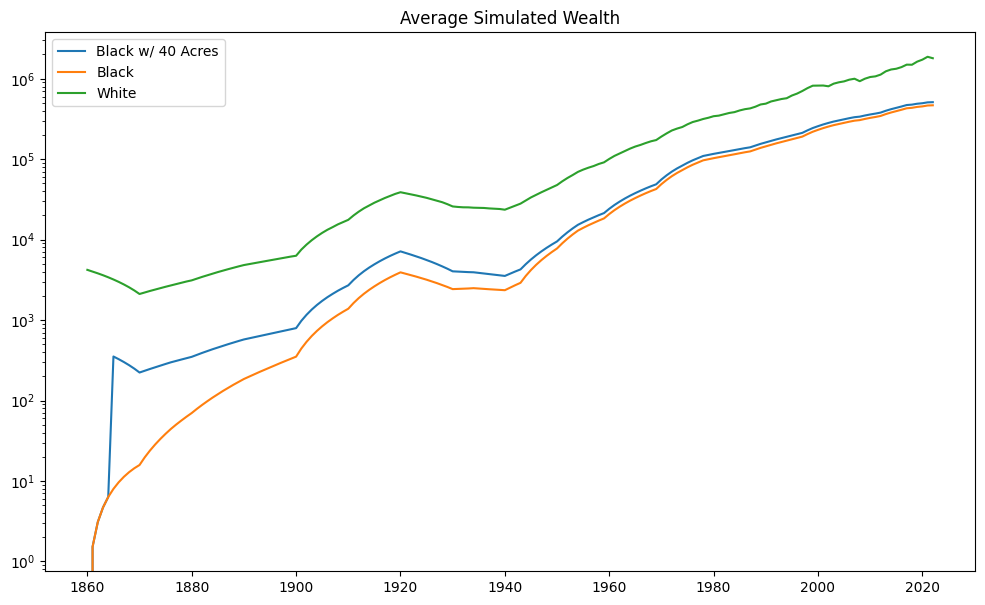

In [26]:

# Plotting average wealths over time in log scale as a simple visualization to understand data simulated
plt.figure(figsize = (12, 7))
plt.semilogy(years, mean_b40, label = 'Black w/ 40 Acres')
plt.semilogy(years, mean_b, label = 'Black')
plt.semilogy(years, mean_w, label = 'White')
plt.title('Average Simulated Wealth')
plt.legend()


